In [1]:
import os

os.chdir('..')

In [2]:
import os
import json
from collections import defaultdict
from nltk.translate.bleu_score import sentence_bleu
from rouge import Rouge
import numpy as np
import pandas as pd



def calculate_bleu(references, candidates):
    scores = [sentence_bleu([ref.split()], cand.split()) for ref, cand in zip(references, candidates)]
    return np.round(np.mean(scores) * 100, 1) if scores else 0

# Function to calculate ROUGE score
def calculate_rouge(references, candidates):
    rouge = Rouge()
    scores = rouge.get_scores(candidates, references, avg=True)
    rouge_1 = np.round(scores['rouge-1']['f'] * 100, 1)
    rouge_2 = np.round(scores['rouge-2']['f'] * 100, 1)
    rouge_l = np.round(scores['rouge-l']['f'] * 100, 1)
    return (rouge_1+rouge_2+rouge_l)/3

# Function to calculate Exact Match score
def calculate_em(references, candidates):
    references = [ref.split("\n\n")[0] for ref in references]
    em_scores = [1 if cal_correct(ref, cand) else 0 for ref, cand in zip(references, candidates)]
    return np.round(np.mean(em_scores) * 100, 1) if em_scores else 0

def cal_correct(generated_answer, expected_answer):
    is_correct = generated_answer.strip().lower().replace(".", "") == expected_answer.strip().lower().replace(".", "")
    return is_correct

In [ ]:
import sys

import torch
from transformers import LlamaForCausalLM, LlamaTokenizer
from tqdm import tqdm
from peft import PeftModel
import json
import numpy as np
from datasets import load_dataset
import torch
import torch.nn as nn
import torch.nn.functional as F

model_size = "7b"
num_runs = 100
model_outputs_folder = f"./adapter_evaluation/outputs_{model_size}/"
config_path = "./config/config2.json"
with open(config_path, 'r') as file:
    lora_configs = json.load(file)

model_names = []
for config in lora_configs:
    model_names.append(config['model_name'])

norm_by_domain_7b = {
    'struct to text': (63.5 + 39.0 + 56.6) / 3,  # Average of rouge-1, rouge-2, rouge-l
    'commonsense': 63.0,
    'sentiment': 90.0,
    'reading comp': 67.7,
    'closed_book QA': 44.0,
    'coreference': 51.0,
    'read.comp.w:commonsense': 70.0,
    'paraphrase': 63.5,
    'nli': 73.1,
    'translation': 13.1
}

norm_by_domain_13b = {
    'struct to text': (65.0 + 40.4 + 58.3) / 3,  # Average of rouge-1, rouge-2, rouge-l
    'commonsense': 69.0,
    'sentiment': 90.0,
    'reading comp': 76.3,
    'closed_book QA': 65.0,
    'coreference': 75.0,
    'read.comp.w:commonsense': 81.0,
    'paraphrase': 76.5,
    'nli': 82.0,
    'translation': 12.8
}

if model_size == "7b":
    norm_by_domain = norm_by_domain_7b
elif model_size == "13b":
    norm_by_domain = norm_by_domain_13b

model_output_dicts_val = {}

for file_name in os.listdir(model_outputs_folder):
    if file_name == '.DS_Store':
        continue

    if file_name.startswith("model_test") or file_name.startswith("degraded_model"):
        continue

    model_index = int(file_name.split('_')[-1].split('.')[0])
    model_index = model_names[model_index]
    model_output_dicts_val[model_index] = {}

    with open(os.path.join(model_outputs_folder, file_name), 'r', encoding='utf-8') as f:
        json_data = json.load(f)

        for sample in json_data:
            metric = sample['metric']
            if metric == 'bleu':
                model_output_dicts_val[model_index][sample['inputs']] = calculate_bleu([sample['targets']], [sample['predicted_answer']])/norm_by_domain[sample['domain']]
            if metric == 'rouge':
                model_output_dicts_val[model_index][sample['inputs']] = calculate_rouge([sample['targets']], [sample['predicted_answer']])/norm_by_domain[sample['domain']]
            if metric == 'em':
                model_output_dicts_val[model_index][sample['inputs']] = calculate_em([sample['targets']], [sample['predicted_answer']])/norm_by_domain[sample['domain']]

/Users/igor/.local/lib/python3.10/site-packages/nltk/translate/bleu_score.py:577: UserWarning: 
The hypothesis contains 0 counts of 4-gram overlaps.
Therefore the BLEU score evaluates to 0, independently of
how many N-gram overlaps of lower order it contains.
Consider using lower n-gram order or use SmoothingFunction()
  warnings.warn(_msg)
/Users/igor/.local/lib/python3.10/site-packages/nltk/translate/bleu_score.py:577: UserWarning: 
The hypothesis contains 0 counts of 2-gram overlaps.
Therefore the BLEU score evaluates to 0, independently of
how many N-gram overlaps of lower order it contains.
Consider using lower n-gram order or use SmoothingFunction()
  warnings.warn(_msg)
/Users/igor/.local/lib/python3.10/site-packages/nltk/translate/bleu_score.py:577: UserWarning: 
The hypothesis contains 0 counts of 3-gram overlaps.
Therefore the BLEU score evaluates to 0, independently of
how many N-gram overlaps of lower order it contains.
Consider using lower n-gram order or use SmoothingFunc

In [4]:
model_outputs_folder = F"./adapter_evaluation/outputs_{model_size}/"
config_path = "./config/config2.json"
with open(config_path, 'r') as file:
    lora_configs = json.load(file)

model_names = []
for config in lora_configs:
    model_names.append(config['model_name'])

model_output_dicts_test = {}

for file_name in os.listdir(model_outputs_folder):
    if not file_name.startswith("model_test"):
        continue

    model_index = int(file_name.split('_')[-1].split('.')[0])
    model_index = model_names[model_index]
    model_output_dicts_test[model_index] = {}

    with open(os.path.join(model_outputs_folder, file_name), 'r', encoding='utf-8') as f:
        json_data = json.load(f)

        for sample in json_data:
            metric = sample['metric']
            if metric == 'bleu':
                model_output_dicts_test[model_index][sample['inputs']] = calculate_bleu([sample['targets']], [sample['predicted_answer']])/norm_by_domain[sample['domain']]
            if metric == 'rouge':
                model_output_dicts_test[model_index][sample['inputs']] = calculate_rouge([sample['targets']], [sample['predicted_answer']])/norm_by_domain[sample['domain']]
            if metric == 'em':
                model_output_dicts_test[model_index][sample['inputs']] = calculate_em([sample['targets']], [sample['predicted_answer']])/norm_by_domain[sample['domain']]

data_path = "./dataset/config_large_flat.json"
if data_path.endswith(".json") or data_path.endswith(".jsonl"):
    dataset = load_dataset("json", data_files=data_path)
else:
    dataset = load_dataset(data_path)

dataset = dataset['train']

In [5]:
from collections import Counter
# Count how many times each model_name appears in the dataset
model_counter = Counter()
for sample in dataset:
    model_counter[sample.get('model_name')] += 1
# Keep only samples whose model_name appears at least 200 times
min_count = 200
filtered_dataset = [sample for sample in dataset if model_counter.get(sample.get('model_name'), 0) >= min_count]
# Summary
try:
    total = len(dataset)
    kept = len(filtered_dataset)
except Exception:
    # Fallback if dataset doesn't support len()
    total = sum(1 for _ in dataset)
    kept = len(filtered_dataset)
print(f'Filtered dataset: kept {kept} / {total} samples (removed {total-kept})')
# Get unique model_names remaining in the filtered dataset
remaining_model_names = sorted({sample.get('model_name') for sample in filtered_dataset})
print(f'Remaining model_names ({len(remaining_model_names)}):')
print(remaining_model_names)
# Expose as a variable for downstream cells
filtered_model_names = remaining_model_names

Filtered dataset: kept 8000 / 8760 samples (removed 760)
Remaining model_names (40):
['anli_r1', 'anli_r2', 'anli_r3', 'arc_challenge', 'bool_q', 'common_gen', 'cosmos_qa', 'dart', 'definite_pronoun_resolution', 'drop', 'e2e_nlg', 'glue_mrpc', 'glue_qqp', 'hellaswag', 'imdb_reviews', 'mnli_matched', 'mnli_mismatched', 'multirc', 'natural_questions', 'openbookqa', 'para_crawl_enes', 'paws_wiki', 'qnli', 'record', 'rte', 'sentiment140', 'squad_v1', 'squad_v2', 'sst2', 'story_cloze', 'trivia_qa', 'web_nlg_en', 'wmt14_enfr', 'wmt16_translate_csen', 'wmt16_translate_deen', 'wmt16_translate_fien', 'wmt16_translate_roen', 'wmt16_translate_ruen', 'wmt16_translate_tren', 'yelp_polarity_reviews']


In [6]:
data_path = "./dataset/combined_test.json"
if data_path.endswith(".json") or data_path.endswith(".jsonl"):
    test_dataset = load_dataset("json", data_files=data_path)
else:
    test_dataset = load_dataset(data_path)

test_dataset = test_dataset['train']

In [7]:
import random

def select_model_sucessive_halving(model_output_dicts, val_dataset, model_names, buget_per_round, seed):
    # Calculate average performance for each model
    random.seed(seed)
    random.shuffle(val_dataset)
    models_remaining = model_names.copy()
    models_per_round = [24, 12, 6, 3]
    scaling_per_round = [2.5, 2.25, 3.375, 5.0625] # Soft start with more samples in the first round and exponentially increase by multiplying with x1.5
    total_cost = 0
    
    # Initialize cumulative performance tracking across all rounds
    cumulative_performances = {model: [] for model in model_names}
    samples_used = 0
    
    for round_idx, num_models in enumerate(models_per_round):
        num_samples = int(buget_per_round * scaling_per_round[round_idx])
        # Get new samples for this round (non-overlapping with previous rounds)
        assert samples_used + num_samples <= len(val_dataset), "Not enough validation samples for the given budget and rounds."
        val_subset = val_dataset[samples_used:samples_used + num_samples]
        samples_used += num_samples
        total_cost += num_samples * len(models_remaining)
        
        # Evaluate remaining models on the new samples
        for model_name in models_remaining:
            for sample in val_subset:
                input_text = sample['inputs']
                if input_text in model_output_dicts[model_name]:
                    cumulative_performances[model_name].append(model_output_dicts[model_name][input_text])
        
        # Calculate average performance using ALL samples seen so far
        model_performances = {}
        for model_name in models_remaining:
            avg_performance = np.mean(cumulative_performances[model_name]) if cumulative_performances[model_name] else 0
            model_performances[model_name] = avg_performance
        
        # Select top models based on cumulative performance
        sorted_models = sorted(model_performances.items(), key=lambda x: x[1], reverse=True)
        models_remaining = [model for model, perf in sorted_models[:num_models]]
        # print(f"Round {round_idx+1}: Selected {len(models_remaining)} models (avg perf: {[f'{perf:.2f}' for _, perf in sorted_models[:num_models]]})")
        # print(f"  Models: {models_remaining}")
    
    return models_remaining[0], total_cost

def select_best_model(model_output_dicts, val_dataset, model_names, num_samples, seed):
    random.seed(seed)
    random.shuffle(val_dataset)
    model_performances = {}
    for model_name in model_names:
        performances = []
        for sample in val_dataset[:num_samples]:
            input_text = sample['inputs']
            if input_text in model_output_dicts[model_name]:
                performances.append(model_output_dicts[model_name][input_text])
        avg_performance = np.mean(performances) if performances else 0
        model_performances[model_name] = avg_performance
    
    # Select the best model
    best_model = max(model_performances.items(), key=lambda x: x[1])[0]
    return best_model, num_samples * len(model_names)

def evaluate_model_on_dataset(model_output_dicts, test_dataset, model_name):
    performances = []
    for sample in test_dataset:
        input_text = sample['inputs']
        if input_text in model_output_dicts[model_name]:
            performances.append(model_output_dicts[model_name][input_text])
    avg_performance = np.mean(performances) if performances else 0
    return avg_performance

In [8]:
def evaluate_sh(initial_budget_per_round):
    perf_total_sh = []
    perf_total_std = []
    for task_name in filtered_model_names:
        val_data = []
        for sample in filtered_dataset:
            if sample['model_name'] == task_name:
                val_data.append(sample)

        test_data = []
        for sample in test_dataset:
            if sample['task'] == task_name:
                test_data.append(sample)

        perf_sh = []
        total_cost = 0
        for i in range(num_runs):
            selected, cost = select_model_sucessive_halving(model_output_dicts_val, val_data, model_names, buget_per_round=initial_budget_per_round, seed=i)
            total_cost += cost # The cost is the same for all tasks since we use the same budget
            perf_sh.append(evaluate_model_on_dataset(model_output_dicts_test, test_data, selected))

        perf_total_sh.append(perf_sh)
        perf_total_std.append(np.array(perf_sh).std())

    return np.array(perf_total_sh).mean(), np.array(perf_total_std).mean(), total_cost / num_runs

In [9]:
def evaluate_naive(num_samples_per_adapter):
    perf_total_naive = []
    perf_total_std = []
    for task_name in filtered_model_names:
        val_data = []
        for sample in filtered_dataset:
            if sample['model_name'] == task_name:
                val_data.append(sample)

        test_data = []
        for sample in test_dataset:
            if sample['task'] == task_name:
                test_data.append(sample)
        
        perf_best = []
        total_cost = 0
        for i in range(num_runs):
            selected, cost = select_best_model(model_output_dicts_val, val_data, model_names, num_samples_per_adapter, seed=i)
            total_cost += cost # The cost is the same for all tasks since we use the same budget
            perf_best.append(evaluate_model_on_dataset(model_output_dicts_test, test_data, selected))

        perf_total_naive.append(perf_best)
        perf_total_std.append(np.array(perf_best).std())

    return np.array(perf_total_naive).mean(), np.array(perf_total_std).mean(), total_cost / num_runs

In [10]:
sh_results = []
sh_std = []
sh_costs = []
for i in range(1,16):
    mean, std, cost = evaluate_sh(i)
    sh_results.append(mean)
    sh_std.append(std)
    sh_costs.append(cost)

In [11]:
naive_results = []
naive_std = []
naive_costs = []
for i in range(10,201,10):
    mean, std, cost = evaluate_naive(i)
    naive_results.append(mean)
    naive_std.append(std)
    naive_costs.append(cost)

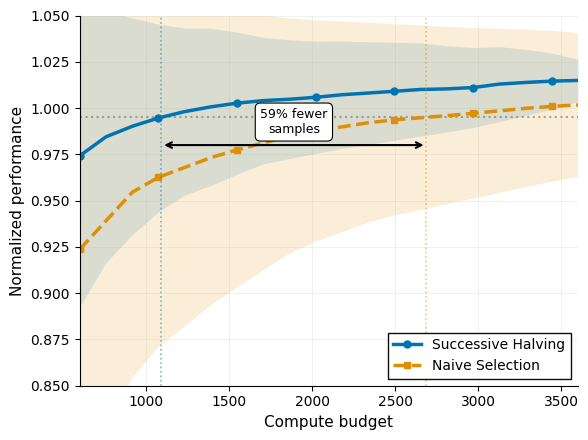


Sample Efficiency at 95% Performance:
  Successive Halving: 1090.9 evaluations
  Naive Selection:    2687.6 evaluations
  Reduction:          59.4% fewer evaluations



In [12]:
import matplotlib.pyplot as plt
import numpy as np

# Interpolation domain (400 to 3200)
sh_x_raw = np.array(sh_costs)  # Successive halving budgets
naive_x_raw = np.array(naive_costs)  # Naive selection budgets
budgets = np.linspace(600, 3600, 20) 

# Interpolate results + std
sh_results_interp = np.interp(budgets, sh_x_raw, sh_results)
sh_std_interp = np.interp(budgets, sh_x_raw, sh_std)
naive_results_interp = np.interp(budgets, naive_x_raw, naive_results)
naive_std_interp = np.interp(budgets, naive_x_raw, naive_std)

# Reference: naive performance at full budget (200 samples)
naive_full_budget_val = naive_results[-1]
target_perf = 0.98  # Find where each method reaches 95% of max

# Find budget where each method reaches target
sh_budget_95 = np.interp(target_perf * naive_full_budget_val, sh_results_interp, budgets)
naive_budget_95 = np.interp(target_perf * naive_full_budget_val, naive_results_interp, budgets)
sample_reduction = (1 - sh_budget_95 / naive_budget_95) * 100

# Publication-quality figure
fig, ax = plt.subplots(figsize=(6, 4.5))  # Standard single-column width

# Colors: colorblind-friendly palette
color_sh = '#0173B2'      # Blue
color_naive = '#DE8F05'   # Orange

# Shaded error regions (±1 std)
ax.fill_between(budgets,
                sh_results_interp - sh_std_interp,
                sh_results_interp + sh_std_interp,
                color=color_sh, alpha=0.15, linewidth=0)

ax.fill_between(budgets,
                naive_results_interp - naive_std_interp,
                naive_results_interp + naive_std_interp,
                color=color_naive, alpha=0.15, linewidth=0)

# Main curves
ax.plot(budgets, sh_results_interp,
        color=color_sh, linewidth=2.5, marker='o', markersize=5,
        markevery=3, label='Successive Halving')

ax.plot(budgets, naive_results_interp,
        color=color_naive, linewidth=2.5, marker='s', markersize=5,
        markevery=3, linestyle='--', label='Naive Selection')

# Horizontal reference line at 95% of max
ref_line_y = target_perf * naive_full_budget_val
ax.axhline(ref_line_y, color='gray', linestyle=':', linewidth=1.5, alpha=0.7, zorder=0)

# Vertical lines showing budget at 95% performance
ax.axvline(sh_budget_95, color=color_sh, linestyle=':', linewidth=1.2, alpha=0.5)
ax.axvline(naive_budget_95, color=color_naive, linestyle=':', linewidth=1.2, alpha=0.5)

# Annotation showing sample reduction (moved higher)
arrow_y = 0.98  # Position arrow higher on y-axis
text_y = 1.0  # Position text slightly below arrow
ax.annotate('',
            xy=(naive_budget_95, arrow_y), xytext=(sh_budget_95, arrow_y),
            arrowprops=dict(arrowstyle='<->', lw=1.5, color='black'))
ax.text((sh_budget_95 + naive_budget_95) / 2, text_y,
        f'{sample_reduction:.0f}% fewer\nsamples',
        ha='center', va='top', fontsize=9,
        bbox=dict(boxstyle='round,pad=0.4', facecolor='white', edgecolor='black', linewidth=0.8))

# Labels and formatting
ax.set_xlabel('Compute budget', fontsize=11, fontweight='normal')
ax.set_ylabel('Normalized performance', fontsize=11, fontweight='normal')
ax.set_ylim(0.85, 1.05)
ax.set_xlim(600, 3600)

# Grid and legend
ax.grid(True, alpha=0.25, linewidth=0.5, linestyle='-')
ax.legend(loc='lower right', fontsize=10, frameon=True, fancybox=False, 
          edgecolor='black', framealpha=0.95)

# Remove top and right spines (cleaner look)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

print(f"\n{'='*60}")
print(f"Sample Efficiency at 95% Performance:")
print(f"  Successive Halving: {sh_budget_95:.1f} evaluations")
print(f"  Naive Selection:    {naive_budget_95:.1f} evaluations")
print(f"  Reduction:          {sample_reduction:.1f}% fewer evaluations")
print(f"{'='*60}\n")

In [13]:
import csv

# Save results to CSV
csv_filename = f"./notebooks/sh_results_{model_size}.csv"

with open(csv_filename, 'w', newline='') as csvfile:
    writer = csv.writer(csvfile)
    
    # Write header
    writer.writerow(['sh_budget', 'sh_results', 'sh_std', 'naive_budget', 'naive_results', 'naive_std', 'num_runs'])
    
    # Write data rows - iterate through max of both lists
    max_len = max(len(sh_results), len(naive_results))
    for i in range(max_len):
        writer.writerow([
            sh_costs[i] if i < len(sh_costs) else '',
            sh_results[i] if i < len(sh_results) else '',
            sh_std[i] if i < len(sh_std) else '',
            naive_costs[i] if i < len(naive_costs) else '',
            naive_results[i] if i < len(naive_results) else '',
            naive_std[i] if i < len(naive_std) else '',
            num_runs,
        ])

print(f"Results saved to {csv_filename}")

Results saved to ./notebooks/sh_results_7b.csv
